## Preprossecing Data


1. import modul

In [ ]:
import pandas as pd
import numpy as np
import nltk
import string
import re

2. memasukan file dataset dalam bentuk csv

In [ ]:
def load_data():
    data_df = pd.read_csv('pokoknya gabung (2).csv')
    return data_df

data = load_data()
data

,full_text,id_str,created_at,username,user_id_str,lang,location,quote_count,reply_count,retweet_count,favorite_count,tweet_url,mentions,mention_count,source,target
0,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kot...,1.838509e+18,2024-09-24 09:23:08+00:00,tempodotco,1.812994e+07,in,Indonesia,0,0,0,1,https://x.com/tempodotco/status/18385094629000...,NaN,0,tempodotco,NaN
1,temen kantor w yang suka day6 dan jarang ngetw...,1.838525e+18,2024-09-24 10:26:01+00:00,bandeusshi,8.452808e+17,in,NaN,762,94,1597,16876,https://x.com/bandeusshi/status/18385252883905...,NaN,0,bandeusshi,NaN
2,halooo temen-temen myday kalo masih bingung ma...,1.838579e+18,2024-09-24 14:00:41+00:00,cachoonne,8.777371e+17,in,24,0,0,0,0,https://x.com/cachoonne/status/183857931039714...,NaN,0,cachoonne,NaN
3,ini detail dan spesifikasi contoh desainnya ya...,1.838874e+18,2024-09-25 09:32:17+00:00,madsimad,4.485532e+07,in,NaN,0,0,0,0,https://x.com/madsimad/status/1838874153413489100,NaN,0,madsimad,NaN
4,yang bikin tiket konser DAY6 pantas untuk dibe...,1.838901e+18,2024-09-25 11:20:25+00:00,youngcyow,1.131197e+18,in,NaN,25,5,152,517,https://x.com/youngcyow/status/183890136444300...,NaN,0,youngcyow,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4793,@guzman_sige emang MBG programnya pak prabowo ...,1.890000e+32,2025-02-10 16:55:48+00:00,mrxlboi,1.640000e+32,in,"DKI Jakarta, Indonesia",0,0,0,0,https://x.com/mrxlboi/status/1888995292588236825,guzman_sige,1,mrxlboi,guzman_sige
4794,@contact030vvv @guzman_sige MBG lebih parah ud...,1.890000e+32,2025-02-10 17:54:15+00:00,Husni_trueblue,3.001025e+09,in,NaN,0,0,0,3,https://x.com/Husni_trueblue/status/1889010002...,"contact030vvv,guzman_sige",2,Husni_trueblue,contact030vvv
4795,@prabowo Dua buah ide Prabowo yang buat bencan...,1.890000e+32,2025-02-10 18:24:49+00:00,birin_jambi,1.622766e+09,in,"Kota Palembang, Sumatera Selat",0,0,0,0,https://x.com/birin_jambi/status/1889017697092...,prabowo,1,birin_jambi,prabowo
4796,Heran sama orang yang milih prabowo. Nohh efis...,1.890000e+32,2025-02-10 18:24:53+00:00,dangercuyy1,1.430000e+32,in,NaN,0,0,0,0,https://x.com/dangercuyy1/status/1889017710467...,NaN,0,dangercuyy1,NaN


3. cleaning data, disini menghapus username dan karater emoji, tanda baca, numerik, link menggunakan loop dengan libary re

In [ ]:
#menghapus username dalam tweet
def remove_pattern(Text, pattern):
    r = re.findall(pattern, str(Text))
    for i in r:
        Text = re.sub(i, '', str(Text))
    return Text
data['remove_user'] = data['full_text'].apply(lambda x: remove_pattern(x, "@[\w]*"))
data.head()

,full_text,id_str,created_at,username,user_id_str,lang,location,quote_count,reply_count,retweet_count,favorite_count,tweet_url,mentions,mention_count,source,target,remove_user
0,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kot...,1.838509e+18,2024-09-24 09:23:08+00:00,tempodotco,1.812994e+07,in,Indonesia,0,0,0,1,https://x.com/tempodotco/status/18385094629000...,NaN,0,tempodotco,NaN,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kot...
1,temen kantor w yang suka day6 dan jarang ngetw...,1.838525e+18,2024-09-24 10:26:01+00:00,bandeusshi,8.452808e+17,in,NaN,762,94,1597,16876,https://x.com/bandeusshi/status/18385252883905...,NaN,0,bandeusshi,NaN,temen kantor w yang suka day6 dan jarang ngetw...
2,halooo temen-temen myday kalo masih bingung ma...,1.838579e+18,2024-09-24 14:00:41+00:00,cachoonne,8.777371e+17,in,24,0,0,0,0,https://x.com/cachoonne/status/183857931039714...,NaN,0,cachoonne,NaN,halooo temen-temen myday kalo masih bingung ma...
3,ini detail dan spesifikasi contoh desainnya ya...,1.838874e+18,2024-09-25 09:32:17+00:00,madsimad,4.485532e+07,in,NaN,0,0,0,0,https://x.com/madsimad/status/1838874153413489100,NaN,0,madsimad,NaN,ini detail dan spesifikasi contoh desainnya ya...
4,yang bikin tiket konser DAY6 pantas untuk dibe...,1.838901e+18,2024-09-25 11:20:25+00:00,youngcyow,1.131197e+18,in,NaN,25,5,152,517,https://x.com/youngcyow/status/183890136444300...,NaN,0,youngcyow,NaN,yang bikin tiket konser DAY6 pantas untuk dibe...


In [ ]:
#cleaning

def cleaning(Text):
    Text = re.sub(r'\$\w*', '', str(Text))         #digunakan untuk menghapus semua kata yang dimulai dengan tanda dolar ($) dan diikuti oleh karakter huruf, angka, atau garis bawah.      #
    Text = re.sub('((www\.[^\s]+)|(https?://[^\s]+))', ' ', Text)     #untuk menghapus semua URL atau tautan web dari teks.
    Text = re.sub('&quot;'," ", Text)         #Digunakan untuk menggantikan setiap kemunculan `&quot;` dengan spasi kosong dalam kolom `text`.
    Text = re.sub(r"\d+", " ", str(Text))         #digunakan untuk menggantikan semua angka dalam teks yang disimpan dalam kolom `text` dengan spasi kosong.
    Text = re.sub(r"[^\w\s]", " ", str(Text))         #digunakan untuk menggantikan semua karakter non-alphanumeric dan non-spasi dalam teks yang disimpan dalam variabel `content` dengan spasi kosong.
    Text = re.sub(r'(.)\1+', r'\1\1', Text)         #Digunakan untuk mengganti dua atau lebih karakter berulang dalam teks dengan hanya dua karakter yang berulang. Misalnya, jika terdapat karakter berulang "eeeee" dalam teks, maka akan digantikan dengan "ee".
    Text = re.sub(r"\s+", " ", str(Text))       #digunakan untuk menggantikan satu atau lebih spasi berturut-turut dalam teks
    Text = re.sub(r'#', '', Text)         #digunakan untuk menghapus semua tanda pagar (#) dalam teks
    Text = re.sub(r'[^a-zA-z0-9]', ' ', str(Text))    #Digunakan untuk menggantikan semua karakter non-alphanumeric dalam teks dengan spasi kosong, sehingga menghapus karakter-karakter tersebut dari teks dan mempertahankan hanya huruf (kapital dan kecil) serta angka.
    Text = re.sub(r'\s\s+', ' ', Text)      #Digunakan untuk menggantikan dua atau lebih spasi berturut-turut dalam teks dengan satu spasi tunggal.
    Text = re.sub(r'^RT[\s]+', '', Text)        #menghapus RT
    Text = re.sub(r'^b[\s]+', '', Text)       #digunakan untuk menghapus spasi di awal teks
    Text = re.sub(r'^link[\s]+', '', Text)      #digunakan untuk menghapus string "link" yang diikuti oleh spasi di awal teks
    return Text

def remove_emoji(Text):
    emoji = re.compile("["
                        u"\U0001F600-\U0001F64F"  # emoticons
                        u"\U0001F300-\U0001F5FF"  # simbol & piktogram
                        u"\U0001F680-\U0001F6FF"  # transportasi & simbol peralatan
                        u"\U0001F1E0-\U0001F1FF"  # bendera negara
                        u"\U00002702-\U000027B0"  # simbol
                        u"\U000024C2-\U0001F251"  # emoji lainnya
                        "]+", flags=re.UNICODE)
    return emoji.sub(r'', Text)

data['cleaning'] = data['remove_user'].apply(cleaning)
data['cleaning'] = data['cleaning'].apply(remove_emoji)
data.head()

,full_text,id_str,created_at,username,user_id_str,lang,location,quote_count,reply_count,retweet_count,favorite_count,tweet_url,mentions,mention_count,source,target,remove_user,cleaning
0,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kot...,1.838509e+18,2024-09-24 09:23:08+00:00,tempodotco,1.812994e+07,in,Indonesia,0,0,0,1,https://x.com/tempodotco/status/18385094629000...,NaN,0,tempodotco,NaN,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kot...,Fakta fakta DAY yang Bakal Konser di Tiga Kota...
1,temen kantor w yang suka day6 dan jarang ngetw...,1.838525e+18,2024-09-24 10:26:01+00:00,bandeusshi,8.452808e+17,in,NaN,762,94,1597,16876,https://x.com/bandeusshi/status/18385252883905...,NaN,0,bandeusshi,NaN,temen kantor w yang suka day6 dan jarang ngetw...,temen kantor w yang suka day dan jarang ngetwe...
2,halooo temen-temen myday kalo masih bingung ma...,1.838579e+18,2024-09-24 14:00:41+00:00,cachoonne,8.777371e+17,in,24,0,0,0,0,https://x.com/cachoonne/status/183857931039714...,NaN,0,cachoonne,NaN,halooo temen-temen myday kalo masih bingung ma...,haloo temen temen myday kalo masih bingung mau...
3,ini detail dan spesifikasi contoh desainnya ya...,1.838874e+18,2024-09-25 09:32:17+00:00,madsimad,4.485532e+07,in,NaN,0,0,0,0,https://x.com/madsimad/status/1838874153413489100,NaN,0,madsimad,NaN,ini detail dan spesifikasi contoh desainnya ya...,ini detail dan spesifikasi contoh desainnya ya...
4,yang bikin tiket konser DAY6 pantas untuk dibe...,1.838901e+18,2024-09-25 11:20:25+00:00,youngcyow,1.131197e+18,in,NaN,25,5,152,517,https://x.com/youngcyow/status/183890136444300...,NaN,0,youngcyow,NaN,yang bikin tiket konser DAY6 pantas untuk dibe...,yang bikin tiket konser DAY pantas untuk dibel...


4. case floding mengubah semua huruf besar menjdi huruf kecil menggunakan .str.lower()

In [ ]:
#case folding - ubah jadi huruf kecil
data['case_folding'] = data['cleaning'].str.lower()
data.head()

,full_text,id_str,created_at,username,user_id_str,lang,location,quote_count,reply_count,retweet_count,favorite_count,tweet_url,mentions,mention_count,source,target,remove_user,cleaning,case_folding
0,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kot...,1.838509e+18,2024-09-24 09:23:08+00:00,tempodotco,1.812994e+07,in,Indonesia,0,0,0,1,https://x.com/tempodotco/status/18385094629000...,NaN,0,tempodotco,NaN,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kot...,Fakta fakta DAY yang Bakal Konser di Tiga Kota...,fakta fakta day yang bakal konser di tiga kota...
1,temen kantor w yang suka day6 dan jarang ngetw...,1.838525e+18,2024-09-24 10:26:01+00:00,bandeusshi,8.452808e+17,in,NaN,762,94,1597,16876,https://x.com/bandeusshi/status/18385252883905...,NaN,0,bandeusshi,NaN,temen kantor w yang suka day6 dan jarang ngetw...,temen kantor w yang suka day dan jarang ngetwe...,temen kantor w yang suka day dan jarang ngetwe...
2,halooo temen-temen myday kalo masih bingung ma...,1.838579e+18,2024-09-24 14:00:41+00:00,cachoonne,8.777371e+17,in,24,0,0,0,0,https://x.com/cachoonne/status/183857931039714...,NaN,0,cachoonne,NaN,halooo temen-temen myday kalo masih bingung ma...,haloo temen temen myday kalo masih bingung mau...,haloo temen temen myday kalo masih bingung mau...
3,ini detail dan spesifikasi contoh desainnya ya...,1.838874e+18,2024-09-25 09:32:17+00:00,madsimad,4.485532e+07,in,NaN,0,0,0,0,https://x.com/madsimad/status/1838874153413489100,NaN,0,madsimad,NaN,ini detail dan spesifikasi contoh desainnya ya...,ini detail dan spesifikasi contoh desainnya ya...,ini detail dan spesifikasi contoh desainnya ya...
4,yang bikin tiket konser DAY6 pantas untuk dibe...,1.838901e+18,2024-09-25 11:20:25+00:00,youngcyow,1.131197e+18,in,NaN,25,5,152,517,https://x.com/youngcyow/status/183890136444300...,NaN,0,youngcyow,NaN,yang bikin tiket konser DAY6 pantas untuk dibe...,yang bikin tiket konser DAY pantas untuk dibel...,yang bikin tiket konser day pantas untuk dibel...


5. duplicate data

In [ ]:
#remove kalimat duplikat dari kolom case_folding
data.drop_duplicates(subset = "case_folding", keep = 'first', inplace = True)
data

,full_text,id_str,created_at,username,user_id_str,lang,location,quote_count,reply_count,retweet_count,favorite_count,tweet_url,mentions,mention_count,source,target,remove_user,cleaning,case_folding
0,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kot...,1.838509e+18,2024-09-24 09:23:08+00:00,tempodotco,1.812994e+07,in,Indonesia,0,0,0,1,https://x.com/tempodotco/status/18385094629000...,NaN,0,tempodotco,NaN,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kot...,Fakta fakta DAY yang Bakal Konser di Tiga Kota...,fakta fakta day yang bakal konser di tiga kota...
1,temen kantor w yang suka day6 dan jarang ngetw...,1.838525e+18,2024-09-24 10:26:01+00:00,bandeusshi,8.452808e+17,in,NaN,762,94,1597,16876,https://x.com/bandeusshi/status/18385252883905...,NaN,0,bandeusshi,NaN,temen kantor w yang suka day6 dan jarang ngetw...,temen kantor w yang suka day dan jarang ngetwe...,temen kantor w yang suka day dan jarang ngetwe...
2,halooo temen-temen myday kalo masih bingung ma...,1.838579e+18,2024-09-24 14:00:41+00:00,cachoonne,8.777371e+17,in,24,0,0,0,0,https://x.com/cachoonne/status/183857931039714...,NaN,0,cachoonne,NaN,halooo temen-temen myday kalo masih bingung ma...,haloo temen temen myday kalo masih bingung mau...,haloo temen temen myday kalo masih bingung mau...
3,ini detail dan spesifikasi contoh desainnya ya...,1.838874e+18,2024-09-25 09:32:17+00:00,madsimad,4.485532e+07,in,NaN,0,0,0,0,https://x.com/madsimad/status/1838874153413489100,NaN,0,madsimad,NaN,ini detail dan spesifikasi contoh desainnya ya...,ini detail dan spesifikasi contoh desainnya ya...,ini detail dan spesifikasi contoh desainnya ya...
4,yang bikin tiket konser DAY6 pantas untuk dibe...,1.838901e+18,2024-09-25 11:20:25+00:00,youngcyow,1.131197e+18,in,NaN,25,5,152,517,https://x.com/youngcyow/status/183890136444300...,NaN,0,youngcyow,NaN,yang bikin tiket konser DAY6 pantas untuk dibe...,yang bikin tiket konser DAY pantas untuk dibel...,yang bikin tiket konser day pantas untuk dibel...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4793,@guzman_sige emang MBG programnya pak prabowo ...,1.890000e+32,2025-02-10 16:55:48+00:00,mrxlboi,1.640000e+32,in,"DKI Jakarta, Indonesia",0,0,0,0,https://x.com/mrxlboi/status/1888995292588236825,guzman_sige,1,mrxlboi,guzman_sige,emang MBG programnya pak prabowo gibran ga en...,emang MBG programnya pak prabowo gibran ga en...,emang mbg programnya pak prabowo gibran ga en...
4794,@contact030vvv @guzman_sige MBG lebih parah ud...,1.890000e+32,2025-02-10 17:54:15+00:00,Husni_trueblue,3.001025e+09,in,NaN,0,0,0,3,https://x.com/Husni_trueblue/status/1889010002...,"contact030vvv,guzman_sige",2,Husni_trueblue,contact030vvv,MBG lebih parah udh gak bergizi lauk gak jel...,MBG lebih parah udh gak bergizi lauk gak jela...,mbg lebih parah udh gak bergizi lauk gak jela...
4795,@prabowo Dua buah ide Prabowo yang buat bencan...,1.890000e+32,2025-02-10 18:24:49+00:00,birin_jambi,1.622766e+09,in,"Kota Palembang, Sumatera Selat",0,0,0,0,https://x.com/birin_jambi/status/1889017697092...,prabowo,1,birin_jambi,prabowo,Dua buah ide Prabowo yang buat bencana yaitu ...,Dua buah ide Prabowo yang buat bencana yaitu ...,dua buah ide prabowo yang buat bencana yaitu ...
4796,Heran sama orang yang milih prabowo. Nohh efis...,1.890000e+32,2025-02-10 18:24:53+00:00,dangercuyy1,1.430000e+32,in,NaN,0,0,0,0,https://x.com/dangercuyy1/status/1889017710467...,NaN,0,dangercuyy1,NaN,Heran sama orang yang milih prabowo. Nohh efis...,Heran sama orang yang milih prabowo Nohh efisi...,heran sama orang yang milih prabowo nohh efisi...


6. tokenisasi mengubah data menjadi daftar kata-kata menggunakan menggunakan library dari NLTK dengan mengimport fungsi word_tokenize dari modul nltk.tokenize.

In [ ]:
#tokenisasi - membagi kalimat jadi perkata (dipisah)
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

def word_tokenize_wrapper(Data):
    return word_tokenize(Data)

data['tokenisasi'] = data['case_folding'].apply(lambda x: word_tokenize_wrapper(x.lower()))
data.head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,full_text,id_str,created_at,username,user_id_str,lang,location,quote_count,reply_count,retweet_count,favorite_count,tweet_url,mentions,mention_count,source,target,remove_user,cleaning,case_folding,tokenisasi
0,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kot...,1.838509e+18,2024-09-24 09:23:08+00:00,tempodotco,1.812994e+07,in,Indonesia,0,0,0,1,https://x.com/tempodotco/status/18385094629000...,NaN,0,tempodotco,NaN,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kot...,Fakta fakta DAY yang Bakal Konser di Tiga Kota...,fakta fakta day yang bakal konser di tiga kota...,"[fakta, fakta, day, yang, bakal, konser, di, t..."
1,temen kantor w yang suka day6 dan jarang ngetw...,1.838525e+18,2024-09-24 10:26:01+00:00,bandeusshi,8.452808e+17,in,NaN,762,94,1597,16876,https://x.com/bandeusshi/status/18385252883905...,NaN,0,bandeusshi,NaN,temen kantor w yang suka day6 dan jarang ngetw...,temen kantor w yang suka day dan jarang ngetwe...,temen kantor w yang suka day dan jarang ngetwe...,"[temen, kantor, w, yang, suka, day, dan, jaran..."
2,halooo temen-temen myday kalo masih bingung ma...,1.838579e+18,2024-09-24 14:00:41+00:00,cachoonne,8.777371e+17,in,24,0,0,0,0,https://x.com/cachoonne/status/183857931039714...,NaN,0,cachoonne,NaN,halooo temen-temen myday kalo masih bingung ma...,haloo temen temen myday kalo masih bingung mau...,haloo temen temen myday kalo masih bingung mau...,"[haloo, temen, temen, myday, kalo, masih, bing..."
3,ini detail dan spesifikasi contoh desainnya ya...,1.838874e+18,2024-09-25 09:32:17+00:00,madsimad,4.485532e+07,in,NaN,0,0,0,0,https://x.com/madsimad/status/1838874153413489100,NaN,0,madsimad,NaN,ini detail dan spesifikasi contoh desainnya ya...,ini detail dan spesifikasi contoh desainnya ya...,ini detail dan spesifikasi contoh desainnya ya...,"[ini, detail, dan, spesifikasi, contoh, desain..."
4,yang bikin tiket konser DAY6 pantas untuk dibe...,1.838901e+18,2024-09-25 11:20:25+00:00,youngcyow,1.131197e+18,in,NaN,25,5,152,517,https://x.com/youngcyow/status/183890136444300...,NaN,0,youngcyow,NaN,yang bikin tiket konser DAY6 pantas untuk dibe...,yang bikin tiket konser DAY pantas untuk dibel...,yang bikin tiket konser day pantas untuk dibel...,"[yang, bikin, tiket, konser, day, pantas, untu..."


7. normalisasi mengganti kalimat slang menjadi formal dengan menggunakan dan membaca dari kamus 'colloquial-indonesian-lexicon.csv' mengecek setiap kata slang akan diganti ke format formal sesuai kamus.

In [ ]:
#Normalisasi-menormalisasikan kata yang non formal menjadi formal sesuai dengan kamus colloquial-indonesian-lexicon
def normalization (Data):
  data_slang = pd.read_excel('/content/colloquial-indonesian-lexicon-2.xlsx')
  dict_slang ={}
  for i in range(data_slang.shape[0]):
    dict_slang[data_slang["slang"][i]]=data_slang["formal"][i]

  drop_slang = []
  for teks in Data:
    normalisasi_teks = [dict_slang[word] if word in dict_slang.keys() else word for word in teks]
    drop_slang.append(normalisasi_teks)

  return drop_slang

data['normalisasi'] = normalization(data['tokenisasi'])
data.head()

,full_text,id_str,created_at,username,user_id_str,lang,location,quote_count,reply_count,retweet_count,...,tweet_url,mentions,mention_count,source,target,remove_user,cleaning,case_folding,tokenisasi,normalisasi
0,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kot...,1.838509e+18,2024-09-24 09:23:08+00:00,tempodotco,1.812994e+07,in,Indonesia,0,0,0,...,https://x.com/tempodotco/status/18385094629000...,NaN,0,tempodotco,NaN,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kot...,Fakta fakta DAY yang Bakal Konser di Tiga Kota...,fakta fakta day yang bakal konser di tiga kota...,"[fakta, fakta, day, yang, bakal, konser, di, t...","[fakta, fakta, day, yang, bakal, konser, di, t..."
1,temen kantor w yang suka day6 dan jarang ngetw...,1.838525e+18,2024-09-24 10:26:01+00:00,bandeusshi,8.452808e+17,in,NaN,762,94,1597,...,https://x.com/bandeusshi/status/18385252883905...,NaN,0,bandeusshi,NaN,temen kantor w yang suka day6 dan jarang ngetw...,temen kantor w yang suka day dan jarang ngetwe...,temen kantor w yang suka day dan jarang ngetwe...,"[temen, kantor, w, yang, suka, day, dan, jaran...","[teman, kantor, gue, yang, suka, day, dan, jar..."
2,halooo temen-temen myday kalo masih bingung ma...,1.838579e+18,2024-09-24 14:00:41+00:00,cachoonne,8.777371e+17,in,24,0,0,0,...,https://x.com/cachoonne/status/183857931039714...,NaN,0,cachoonne,NaN,halooo temen-temen myday kalo masih bingung ma...,haloo temen temen myday kalo masih bingung mau...,haloo temen temen myday kalo masih bingung mau...,"[haloo, temen, temen, myday, kalo, masih, bing...","[haloo, teman, teman, myday, kalo, masih, bing..."
3,ini detail dan spesifikasi contoh desainnya ya...,1.838874e+18,2024-09-25 09:32:17+00:00,madsimad,4.485532e+07,in,NaN,0,0,0,...,https://x.com/madsimad/status/1838874153413489100,NaN,0,madsimad,NaN,ini detail dan spesifikasi contoh desainnya ya...,ini detail dan spesifikasi contoh desainnya ya...,ini detail dan spesifikasi contoh desainnya ya...,"[ini, detail, dan, spesifikasi, contoh, desain...","[ini, detail, dan, spesifikasi, contoh, desain..."
4,yang bikin tiket konser DAY6 pantas untuk dibe...,1.838901e+18,2024-09-25 11:20:25+00:00,youngcyow,1.131197e+18,in,NaN,25,5,152,...,https://x.com/youngcyow/status/183890136444300...,NaN,0,youngcyow,NaN,yang bikin tiket konser DAY6 pantas untuk dibe...,yang bikin tiket konser DAY pantas untuk dibel...,yang bikin tiket konser day pantas untuk dibel...,"[yang, bikin, tiket, konser, day, pantas, untu...","[yang, bikin, tiket, konser, day, pantas, untu..."


8. Konversi Negation (Negasi) itu kata-kata yang mengubah makna suatu kalimat menjadi kebalikannya (biasanya dari positif ke negatif atau sebaliknya)

In [ ]:
# Konversi Negasi
def convert_negation(tokens):
    negation_words = ['tidak', 'bukan', 'jangan', 'enggak', 'ga', 'gak', 'belum', 'belom', 'tiada', 'tak']  #bisa tambahkan lebih banyak kata negasi di sini
    result = []
    negate = False

    for i in range(len(tokens)):
        if tokens[i] in negation_words and i + 1 < len(tokens):
            # Menggabungkan kata negasi dengan kata berikutnya
            negated_word = tokens[i] + '_' + tokens[i + 1]
            result.append(negated_word)
            negate = True
        elif negate:
            negate = False  # Melewati kata yang sudah digabungkan dengan negasi
        else:
            result.append(tokens[i])

    return result

data['negation_converted_text'] = data['normalisasi'].apply(convert_negation)
data.head()

,full_text,id_str,created_at,username,user_id_str,lang,location,quote_count,reply_count,retweet_count,...,mentions,mention_count,source,target,remove_user,cleaning,case_folding,tokenisasi,normalisasi,negation_converted_text
0,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kot...,1.838509e+18,2024-09-24 09:23:08+00:00,tempodotco,1.812994e+07,in,Indonesia,0,0,0,...,NaN,0,tempodotco,NaN,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kot...,Fakta fakta DAY yang Bakal Konser di Tiga Kota...,fakta fakta day yang bakal konser di tiga kota...,"[fakta, fakta, day, yang, bakal, konser, di, t...","[fakta, fakta, day, yang, bakal, konser, di, t...","[fakta, fakta, day, yang, bakal, konser, di, t..."
1,temen kantor w yang suka day6 dan jarang ngetw...,1.838525e+18,2024-09-24 10:26:01+00:00,bandeusshi,8.452808e+17,in,NaN,762,94,1597,...,NaN,0,bandeusshi,NaN,temen kantor w yang suka day6 dan jarang ngetw...,temen kantor w yang suka day dan jarang ngetwe...,temen kantor w yang suka day dan jarang ngetwe...,"[temen, kantor, w, yang, suka, day, dan, jaran...","[teman, kantor, gue, yang, suka, day, dan, jar...","[teman, kantor, gue, yang, suka, day, dan, jar..."
2,halooo temen-temen myday kalo masih bingung ma...,1.838579e+18,2024-09-24 14:00:41+00:00,cachoonne,8.777371e+17,in,24,0,0,0,...,NaN,0,cachoonne,NaN,halooo temen-temen myday kalo masih bingung ma...,haloo temen temen myday kalo masih bingung mau...,haloo temen temen myday kalo masih bingung mau...,"[haloo, temen, temen, myday, kalo, masih, bing...","[haloo, teman, teman, myday, kalo, masih, bing...","[haloo, teman, teman, myday, kalo, masih, bing..."
3,ini detail dan spesifikasi contoh desainnya ya...,1.838874e+18,2024-09-25 09:32:17+00:00,madsimad,4.485532e+07,in,NaN,0,0,0,...,NaN,0,madsimad,NaN,ini detail dan spesifikasi contoh desainnya ya...,ini detail dan spesifikasi contoh desainnya ya...,ini detail dan spesifikasi contoh desainnya ya...,"[ini, detail, dan, spesifikasi, contoh, desain...","[ini, detail, dan, spesifikasi, contoh, desain...","[ini, detail, dan, spesifikasi, contoh, desain..."
4,yang bikin tiket konser DAY6 pantas untuk dibe...,1.838901e+18,2024-09-25 11:20:25+00:00,youngcyow,1.131197e+18,in,NaN,25,5,152,...,NaN,0,youngcyow,NaN,yang bikin tiket konser DAY6 pantas untuk dibe...,yang bikin tiket konser DAY pantas untuk dibel...,yang bikin tiket konser day pantas untuk dibel...,"[yang, bikin, tiket, konser, day, pantas, untu...","[yang, bikin, tiket, konser, day, pantas, untu...","[yang, bikin, tiket, konser, day, pantas, untu..."


9. Stopword Removal/Removing. Menghapus kata yang tidak memiliki makna penting.

In [ ]:
#Stopword removal - filtering/menghapus kata yang tidak ada didalam kamus corpus nltk
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Bahasa Indonesia stopwords
list_stopwords_id = stopwords.words('indonesian')
list_stopwords_id.extend(['yg', 'dg', 'rt', 'dgn', 'ny', 'gt', 'klo',
                       'kalo', 'amp', 'xbf', 'xad', 'xef',
                       'xe', 'ga', 'krn', 'nya', 'nih', 'sih',
                       'si', 'xc', 'tdk', 'tuh', 'utk', 'ya',
                       'jd', 'jgn', 'sdh', 'xae', 'n', 't',
                       'nyg', 'hehe', 'pen', 'u', 'nan', 'loh', 'rt',
                       '&', 'yah', 'no', 'je', 'xbb', 'xb', 'sch',
                       'injirrr', 'ah', 'oena', 'bu', 'eh', 'xac', 'xbc', 'xf', 'xa'])

list_stopwords = set(list_stopwords_id)
list_stopwords.discard('tahu')
list_stopwords.discard('saja')
list_stopwords.discard('dulu')
list_stopwords.discard('mau')
list_stopwords.discard('akan')
list_stopwords.discard('paling')
list_stopwords.discard('lain')
list_stopwords.discard('yang')

def stopwords_removal(Text):
    return [word for word in Text if word not in list_stopwords]

data['stopword_removal'] = data['negation_converted_text'].apply(stopwords_removal)
data.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,full_text,id_str,created_at,username,user_id_str,lang,location,quote_count,reply_count,retweet_count,...,mention_count,source,target,remove_user,cleaning,case_folding,tokenisasi,normalisasi,negation_converted_text,stopword_removal
0,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kot...,1.838509e+18,2024-09-24 09:23:08+00:00,tempodotco,1.812994e+07,in,Indonesia,0,0,0,...,0,tempodotco,NaN,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kot...,Fakta fakta DAY yang Bakal Konser di Tiga Kota...,fakta fakta day yang bakal konser di tiga kota...,"[fakta, fakta, day, yang, bakal, konser, di, t...","[fakta, fakta, day, yang, bakal, konser, di, t...","[fakta, fakta, day, yang, bakal, konser, di, t...","[fakta, fakta, day, yang, konser, kota, indone..."
1,temen kantor w yang suka day6 dan jarang ngetw...,1.838525e+18,2024-09-24 10:26:01+00:00,bandeusshi,8.452808e+17,in,NaN,762,94,1597,...,0,bandeusshi,NaN,temen kantor w yang suka day6 dan jarang ngetw...,temen kantor w yang suka day dan jarang ngetwe...,temen kantor w yang suka day dan jarang ngetwe...,"[temen, kantor, w, yang, suka, day, dan, jaran...","[teman, kantor, gue, yang, suka, day, dan, jar...","[teman, kantor, gue, yang, suka, day, dan, jar...","[teman, kantor, gue, yang, suka, day, jarang, ..."
2,halooo temen-temen myday kalo masih bingung ma...,1.838579e+18,2024-09-24 14:00:41+00:00,cachoonne,8.777371e+17,in,24,0,0,0,...,0,cachoonne,NaN,halooo temen-temen myday kalo masih bingung ma...,haloo temen temen myday kalo masih bingung mau...,haloo temen temen myday kalo masih bingung mau...,"[haloo, temen, temen, myday, kalo, masih, bing...","[haloo, teman, teman, myday, kalo, masih, bing...","[haloo, teman, teman, myday, kalo, masih, bing...","[haloo, teman, teman, myday, bingung, mau, mak..."
3,ini detail dan spesifikasi contoh desainnya ya...,1.838874e+18,2024-09-25 09:32:17+00:00,madsimad,4.485532e+07,in,NaN,0,0,0,...,0,madsimad,NaN,ini detail dan spesifikasi contoh desainnya ya...,ini detail dan spesifikasi contoh desainnya ya...,ini detail dan spesifikasi contoh desainnya ya...,"[ini, detail, dan, spesifikasi, contoh, desain...","[ini, detail, dan, spesifikasi, contoh, desain...","[ini, detail, dan, spesifikasi, contoh, desain...","[detail, spesifikasi, contoh, desainnya, form,..."
4,yang bikin tiket konser DAY6 pantas untuk dibe...,1.838901e+18,2024-09-25 11:20:25+00:00,youngcyow,1.131197e+18,in,NaN,25,5,152,...,0,youngcyow,NaN,yang bikin tiket konser DAY6 pantas untuk dibe...,yang bikin tiket konser DAY pantas untuk dibel...,yang bikin tiket konser day pantas untuk dibel...,"[yang, bikin, tiket, konser, day, pantas, untu...","[yang, bikin, tiket, konser, day, pantas, untu...","[yang, bikin, tiket, konser, day, pantas, untu...","[yang, bikin, tiket, konser, day, dibeli, musi..."


10. Stemming proses mengahpus imbuhan. Disini menggunakan Library pysastrawi

In [ ]:
# Install library yang dibutuhkan
!pip install swifter
!pip install PySastrawi

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import swifter

# Buat stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Fungsi wrapper untuk stemming
def stemmed_wrapper(term):
    return stemmer.stem(term)

# Dictionary untuk menyimpan hasil stemming
term_dict = {}

# Daftar kata yang ingin dikecualikan dari stemming
exception_words = {"pemilu": "pemilu", "mengaku": "ngaku", "pemerintah": "pemerintah", "mengasih": "mengasih", "tahu": "tau", "kabur saja dulu": "kabur saja dulu", "saja": "saja", "dulu": "dulu", "tahunn": "tahun", "kabur": "kabur", "perawat": "perawat", "dipersilakan": "silakan", "wkwkwk": "haha"}

# Inisialisasi term_dict berdasarkan data stopword removal, hanya untuk kata yang belum ada di term_dict
for Data in data['stopword_removal']:
    for term in Data:
        if term not in term_dict:
            if term in exception_words:
                term_dict[term] = exception_words[term]  # Gunakan kata dari exception_words
            else:
                term_dict[term] = stemmed_wrapper(term)  # Stemming untuk kata lainnya

print(len(term_dict))
print("------------------------")

# Proses stemming, kecuali untuk kata-kata dalam exception_words
for term in term_dict:
    # Cek jika term ada di exception_words, jika ya, gunakan nilai dari exception_words
    if term in exception_words:
        term_dict[term] = exception_words[term]
    else:
        term_dict[term] = stemmed_wrapper(term)
    print(term, ":", term_dict[term])

print(term_dict)
print("------------------------")

# Fungsi untuk menerapkan stemming dengan pengecualian
def apply_stemmed_term(Data):
    stemmed_terms = []
    for term in Data:
        if term in exception_words:
            # Menggunakan kata dari daftar pengecualian
            stemmed_terms.append(exception_words[term])
        else:
            # Menggunakan hasil stemming dari term_dict
            stemmed_terms.append(term_dict.get(term, term))
    return stemmed_terms

# Terapkan stemming dengan pengecualian
data['stemming'] = data['stopword_removal'].swifter.apply(apply_stemmed_term)
data.head()

Output streaming akan dipotong hingga 5000 baris terakhir.
bobroknya : bobrok
supply : supply
nyerep : nyerep
pekerja : kerja
regulasi : regulasi
petani : tani
produsen : produsen
bukan_dari : bukan dari
import : import
keputer : puter
warteg : warteg
berlokasi : lokasi
ruko : ruko
dicemooh : cemooh
pesimis : pesimis
jangan_dikorupsi : jangan korupsi
usul : usul
stempel : stempel
pengikut : ikut
menyumbangkan : sumbang
kekayaannya : kaya
enggak_jawab : enggak jawab
bpjs : bpjs
gapok : gapok
memaksa : paksa
kupon : kupon
ditukar : tukar
nombokin : nombokin
penurunan : turun
lawatan : lawat
tiongkok : tiongkok
rmb : rmb
setara : tara
daging : daging
berkewajiban : wajib
melaksanakan : laksana
didik : didik
ber : ber
gratisan : gratis
kebantu : bantu
buatan : buat
simpati : simpati
pendanaan : dana
enggak_gemuknya : enggak gemuk
penyebab : sebab
devisit : devisit
kebohongan : bohong
menutupi : tutup
boros : boros
diperas : peras
kadernya : kader
dungu : dungu
mencerdaskan : cerdas
kkn : k

Pandas Apply:   0%|          | 0/4793 [00:00<?, ?it/s]

,full_text,id_str,created_at,username,user_id_str,lang,location,quote_count,reply_count,retweet_count,...,source,target,remove_user,cleaning,case_folding,tokenisasi,normalisasi,negation_converted_text,stopword_removal,stemming
0,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kot...,1.838509e+18,2024-09-24 09:23:08+00:00,tempodotco,1.812994e+07,in,Indonesia,0,0,0,...,tempodotco,NaN,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kot...,Fakta fakta DAY yang Bakal Konser di Tiga Kota...,fakta fakta day yang bakal konser di tiga kota...,"[fakta, fakta, day, yang, bakal, konser, di, t...","[fakta, fakta, day, yang, bakal, konser, di, t...","[fakta, fakta, day, yang, bakal, konser, di, t...","[fakta, fakta, day, yang, konser, kota, indone...","[fakta, fakta, day, yang, konser, kota, indone..."
1,temen kantor w yang suka day6 dan jarang ngetw...,1.838525e+18,2024-09-24 10:26:01+00:00,bandeusshi,8.452808e+17,in,NaN,762,94,1597,...,bandeusshi,NaN,temen kantor w yang suka day6 dan jarang ngetw...,temen kantor w yang suka day dan jarang ngetwe...,temen kantor w yang suka day dan jarang ngetwe...,"[temen, kantor, w, yang, suka, day, dan, jaran...","[teman, kantor, gue, yang, suka, day, dan, jar...","[teman, kantor, gue, yang, suka, day, dan, jar...","[teman, kantor, gue, yang, suka, day, jarang, ...","[teman, kantor, gue, yang, suka, day, jarang, ..."
2,halooo temen-temen myday kalo masih bingung ma...,1.838579e+18,2024-09-24 14:00:41+00:00,cachoonne,8.777371e+17,in,24,0,0,0,...,cachoonne,NaN,halooo temen-temen myday kalo masih bingung ma...,haloo temen temen myday kalo masih bingung mau...,haloo temen temen myday kalo masih bingung mau...,"[haloo, temen, temen, myday, kalo, masih, bing...","[haloo, teman, teman, myday, kalo, masih, bing...","[haloo, teman, teman, myday, kalo, masih, bing...","[haloo, teman, teman, myday, bingung, mau, mak...","[haloo, teman, teman, myday, bingung, mau, mak..."
3,ini detail dan spesifikasi contoh desainnya ya...,1.838874e+18,2024-09-25 09:32:17+00:00,madsimad,4.485532e+07,in,NaN,0,0,0,...,madsimad,NaN,ini detail dan spesifikasi contoh desainnya ya...,ini detail dan spesifikasi contoh desainnya ya...,ini detail dan spesifikasi contoh desainnya ya...,"[ini, detail, dan, spesifikasi, contoh, desain...","[ini, detail, dan, spesifikasi, contoh, desain...","[ini, detail, dan, spesifikasi, contoh, desain...","[detail, spesifikasi, contoh, desainnya, form,...","[detail, spesifikasi, contoh, desain, form, pe..."
4,yang bikin tiket konser DAY6 pantas untuk dibe...,1.838901e+18,2024-09-25 11:20:25+00:00,youngcyow,1.131197e+18,in,NaN,25,5,152,...,youngcyow,NaN,yang bikin tiket konser DAY6 pantas untuk dibe...,yang bikin tiket konser DAY pantas untuk dibel...,yang bikin tiket konser day pantas untuk dibel...,"[yang, bikin, tiket, konser, day, pantas, untu...","[yang, bikin, tiket, konser, day, pantas, untu...","[yang, bikin, tiket, konser, day, pantas, untu...","[yang, bikin, tiket, konser, day, dibeli, musi...","[yang, bikin, tiket, konser, day, beli, musika..."


11.To Sentence yaitu mengubah bentuk list token menjadi sentence atau kalimat.

In [ ]:
#To Sentence/Untokenized
stemming = data[['stemming']]

def to_fit_sentence(Tweets):
    Tweets = np.array(Tweets)
    Tweets = ' '.join(Tweets)

    return Tweets

data['to_sentence'] = data['stemming'].apply(lambda x: to_fit_sentence(x))
data.head()

,full_text,id_str,created_at,username,user_id_str,lang,location,quote_count,reply_count,retweet_count,...,target,remove_user,cleaning,case_folding,tokenisasi,normalisasi,negation_converted_text,stopword_removal,stemming,to_sentence
0,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kot...,1.838509e+18,2024-09-24 09:23:08+00:00,tempodotco,1.812994e+07,in,Indonesia,0,0,0,...,NaN,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kot...,Fakta fakta DAY yang Bakal Konser di Tiga Kota...,fakta fakta day yang bakal konser di tiga kota...,"[fakta, fakta, day, yang, bakal, konser, di, t...","[fakta, fakta, day, yang, bakal, konser, di, t...","[fakta, fakta, day, yang, bakal, konser, di, t...","[fakta, fakta, day, yang, konser, kota, indone...","[fakta, fakta, day, yang, konser, kota, indone...",fakta fakta day yang konser kota indonesia tem...
1,temen kantor w yang suka day6 dan jarang ngetw...,1.838525e+18,2024-09-24 10:26:01+00:00,bandeusshi,8.452808e+17,in,NaN,762,94,1597,...,NaN,temen kantor w yang suka day6 dan jarang ngetw...,temen kantor w yang suka day dan jarang ngetwe...,temen kantor w yang suka day dan jarang ngetwe...,"[temen, kantor, w, yang, suka, day, dan, jaran...","[teman, kantor, gue, yang, suka, day, dan, jar...","[teman, kantor, gue, yang, suka, day, dan, jar...","[teman, kantor, gue, yang, suka, day, jarang, ...","[teman, kantor, gue, yang, suka, day, jarang, ...",teman kantor gue yang suka day jarang ngetweet...
2,halooo temen-temen myday kalo masih bingung ma...,1.838579e+18,2024-09-24 14:00:41+00:00,cachoonne,8.777371e+17,in,24,0,0,0,...,NaN,halooo temen-temen myday kalo masih bingung ma...,haloo temen temen myday kalo masih bingung mau...,haloo temen temen myday kalo masih bingung mau...,"[haloo, temen, temen, myday, kalo, masih, bing...","[haloo, teman, teman, myday, kalo, masih, bing...","[haloo, teman, teman, myday, kalo, masih, bing...","[haloo, teman, teman, myday, bingung, mau, mak...","[haloo, teman, teman, myday, bingung, mau, mak...",haloo teman teman myday bingung mau makan kons...
3,ini detail dan spesifikasi contoh desainnya ya...,1.838874e+18,2024-09-25 09:32:17+00:00,madsimad,4.485532e+07,in,NaN,0,0,0,...,NaN,ini detail dan spesifikasi contoh desainnya ya...,ini detail dan spesifikasi contoh desainnya ya...,ini detail dan spesifikasi contoh desainnya ya...,"[ini, detail, dan, spesifikasi, contoh, desain...","[ini, detail, dan, spesifikasi, contoh, desain...","[ini, detail, dan, spesifikasi, contoh, desain...","[detail, spesifikasi, contoh, desainnya, form,...","[detail, spesifikasi, contoh, desain, form, pe...",detail spesifikasi contoh desain form pesan da...
4,yang bikin tiket konser DAY6 pantas untuk dibe...,1.838901e+18,2024-09-25 11:20:25+00:00,youngcyow,1.131197e+18,in,NaN,25,5,152,...,NaN,yang bikin tiket konser DAY6 pantas untuk dibe...,yang bikin tiket konser DAY pantas untuk dibel...,yang bikin tiket konser day pantas untuk dibel...,"[yang, bikin, tiket, konser, day, pantas, untu...","[yang, bikin, tiket, konser, day, pantas, untu...","[yang, bikin, tiket, konser, day, pantas, untu...","[yang, bikin, tiket, konser, day, dibeli, musi...","[yang, bikin, tiket, konser, day, beli, musika...",yang bikin tiket konser day beli musikalitas d...


12. Pembersihan Noise

In [ ]:
# Fungsi untuk mengganti karakter '_' dengan spasi
def replace_underscore_with_space(Data):
    # Check if the data is a string before applying re.sub
    if isinstance(Data, str):
        return re.sub(r'_', ' ', Data)
    else:
        return Data # Return non-string data as is

data['to_sentence'] = data['to_sentence'].apply(replace_underscore_with_space)
data.head()

,full_text,id_str,created_at,username,user_id_str,lang,location,quote_count,reply_count,retweet_count,...,target,remove_user,cleaning,case_folding,tokenisasi,normalisasi,negation_converted_text,stopword_removal,stemming,to_sentence
0,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kot...,1.838509e+18,2024-09-24 09:23:08+00:00,tempodotco,1.812994e+07,in,Indonesia,0,0,0,...,NaN,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kot...,Fakta fakta DAY yang Bakal Konser di Tiga Kota...,fakta fakta day yang bakal konser di tiga kota...,"[fakta, fakta, day, yang, bakal, konser, di, t...","[fakta, fakta, day, yang, bakal, konser, di, t...","[fakta, fakta, day, yang, bakal, konser, di, t...","[fakta, fakta, day, yang, konser, kota, indone...","[fakta, fakta, day, yang, konser, kota, indone...",fakta fakta day yang konser kota indonesia tem...
1,temen kantor w yang suka day6 dan jarang ngetw...,1.838525e+18,2024-09-24 10:26:01+00:00,bandeusshi,8.452808e+17,in,NaN,762,94,1597,...,NaN,temen kantor w yang suka day6 dan jarang ngetw...,temen kantor w yang suka day dan jarang ngetwe...,temen kantor w yang suka day dan jarang ngetwe...,"[temen, kantor, w, yang, suka, day, dan, jaran...","[teman, kantor, gue, yang, suka, day, dan, jar...","[teman, kantor, gue, yang, suka, day, dan, jar...","[teman, kantor, gue, yang, suka, day, jarang, ...","[teman, kantor, gue, yang, suka, day, jarang, ...",teman kantor gue yang suka day jarang ngetweet...
2,halooo temen-temen myday kalo masih bingung ma...,1.838579e+18,2024-09-24 14:00:41+00:00,cachoonne,8.777371e+17,in,24,0,0,0,...,NaN,halooo temen-temen myday kalo masih bingung ma...,haloo temen temen myday kalo masih bingung mau...,haloo temen temen myday kalo masih bingung mau...,"[haloo, temen, temen, myday, kalo, masih, bing...","[haloo, teman, teman, myday, kalo, masih, bing...","[haloo, teman, teman, myday, kalo, masih, bing...","[haloo, teman, teman, myday, bingung, mau, mak...","[haloo, teman, teman, myday, bingung, mau, mak...",haloo teman teman myday bingung mau makan kons...
3,ini detail dan spesifikasi contoh desainnya ya...,1.838874e+18,2024-09-25 09:32:17+00:00,madsimad,4.485532e+07,in,NaN,0,0,0,...,NaN,ini detail dan spesifikasi contoh desainnya ya...,ini detail dan spesifikasi contoh desainnya ya...,ini detail dan spesifikasi contoh desainnya ya...,"[ini, detail, dan, spesifikasi, contoh, desain...","[ini, detail, dan, spesifikasi, contoh, desain...","[ini, detail, dan, spesifikasi, contoh, desain...","[detail, spesifikasi, contoh, desainnya, form,...","[detail, spesifikasi, contoh, desain, form, pe...",detail spesifikasi contoh desain form pesan da...
4,yang bikin tiket konser DAY6 pantas untuk dibe...,1.838901e+18,2024-09-25 11:20:25+00:00,youngcyow,1.131197e+18,in,NaN,25,5,152,...,NaN,yang bikin tiket konser DAY6 pantas untuk dibe...,yang bikin tiket konser DAY pantas untuk dibel...,yang bikin tiket konser day pantas untuk dibel...,"[yang, bikin, tiket, konser, day, pantas, untu...","[yang, bikin, tiket, konser, day, pantas, untu...","[yang, bikin, tiket, konser, day, pantas, untu...","[yang, bikin, tiket, konser, day, dibeli, musi...","[yang, bikin, tiket, konser, day, beli, musika...",yang bikin tiket konser day beli musikalitas d...


In [ ]:
print(data.isnull().sum())

full_text                     0
id_str                        0
created_at                    0
username                      0
user_id_str                   0
lang                          0
location                   3074
quote_count                   0
reply_count                   0
retweet_count                 0
favorite_count                0
tweet_url                     0
mentions                   1651
mention_count                 0
source                        0
target                     1677
remove_user                   0
cleaning                      0
case_folding                  0
tokenisasi                    0
normalisasi                   0
negation_converted_text       0
stopword_removal              0
stemming                      0
to_sentence                   0
dtype: int64


In [ ]:
data['location'] = data['location'].fillna(data['location'].mode()[0])

In [ ]:
data['mentions'] = data['mentions'].fillna(data['mentions'].mode()[0])


In [ ]:
data['target'] = data['target'].fillna(data['target'].mode()[0])


In [ ]:
print(data.isnull().sum())

full_text                  0
id_str                     0
created_at                 0
username                   0
user_id_str                0
lang                       0
location                   0
quote_count                0
reply_count                0
retweet_count              0
favorite_count             0
tweet_url                  0
mentions                   0
mention_count              0
source                     0
target                     0
remove_user                0
cleaning                   0
case_folding               0
tokenisasi                 0
normalisasi                0
negation_converted_text    0
stopword_removal           0
stemming                   0
to_sentence                0
dtype: int64


13. simpan hasil data pre prossecing

In [ ]:
#simpan kedalam csv
data.to_csv('hasil-preprocessing_data.csv', sep=',', index=False)

## Labeling

In [ ]:
#modul untuk dataframe
import pandas as pd

#modul yang dibutuhkan untuk translate
!pip install googletrans==3.1.0a0
import googletrans
from googletrans import Translator
translator = Translator()
pd.set_option('max_colwidth', 300)

#Modul Labelin Sentimen
from textblob import TextBlob

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 3.2 MB/s eta 0:00:00
  Created wheel for googletrans: filename=googletrans-3.1.0a0-py3-none-any.whl size=16353 sha256=46712eeb01e74a62372664420f30e19f577e953777ef3380eebd216e6fcae1a0
  Stored in directory: /root/.cache/pip/wheels/81/f2/e0/d578821d723b473d18610ea93810e4a5402463919f07e603d9
Successfully built googletrans
  Attempting uninstall: hyperframe
    Found existing installation: hyperframe 6.1.0
    Uninstalling hyperframe

In [ ]:
#masukan data hasil preprocessing
df = pd.read_csv('/content/hasil-preprocessing_data.csv')
df.head()

,full_text,id_str,created_at,username,user_id_str,lang,location,quote_count,reply_count,retweet_count,...,target,remove_user,cleaning,case_folding,tokenisasi,normalisasi,negation_converted_text,stopword_removal,stemming,to_sentence
0,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kota di Indonesia https://t.co/H8KAiLzktM #TempoSeleb,1.838509e+18,2024-09-24 09:23:08+00:00,tempodotco,1.812994e+07,in,Indonesia,0,0,0,...,mecimapro,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kota di Indonesia https://t.co/H8KAiLzktM #TempoSeleb,Fakta fakta DAY yang Bakal Konser di Tiga Kota di Indonesia TempoSeleb,fakta fakta day yang bakal konser di tiga kota di indonesia temposeleb,"['fakta', 'fakta', 'day', 'yang', 'bakal', 'konser', 'di', 'tiga', 'kota', 'di', 'indonesia', 'temposeleb']","['fakta', 'fakta', 'day', 'yang', 'bakal', 'konser', 'di', 'tiga', 'kota', 'di', 'indonesia', 'temposeleb']","['fakta', 'fakta', 'day', 'yang', 'bakal', 'konser', 'di', 'tiga', 'kota', 'di', 'indonesia', 'temposeleb']","['fakta', 'fakta', 'day', 'yang', 'konser', 'kota', 'indonesia', 'temposeleb']","['fakta', 'fakta', 'day', 'yang', 'konser', 'kota', 'indonesia', 'temposeleb']",fakta fakta day yang konser kota indonesia temposeleb
1,temen kantor w yang suka day6 dan jarang ngetweet mau ngasih freebies pas konser terus w bilang biasanya nanti yang terima freebies suka ngajak mutualan di twitter terus dia bilang kalo gw kasih LinkedIn gw aja boleh ga? nanti ngobrolnya di LinkedIn,1.838525e+18,2024-09-24 10:26:01+00:00,bandeusshi,8.452808e+17,in,Indonesia,762,94,1597,...,mecimapro,temen kantor w yang suka day6 dan jarang ngetweet mau ngasih freebies pas konser terus w bilang biasanya nanti yang terima freebies suka ngajak mutualan di twitter terus dia bilang kalo gw kasih LinkedIn gw aja boleh ga? nanti ngobrolnya di LinkedIn,temen kantor w yang suka day dan jarang ngetweet mau ngasih freebies pas konser terus w bilang biasanya nanti yang terima freebies suka ngajak mutualan di twitter terus dia bilang kalo gw kasih LinkedIn gw aja boleh ga nanti ngobrolnya di LinkedIn,temen kantor w yang suka day dan jarang ngetweet mau ngasih freebies pas konser terus w bilang biasanya nanti yang terima freebies suka ngajak mutualan di twitter terus dia bilang kalo gw kasih linkedin gw aja boleh ga nanti ngobrolnya di linkedin,"['temen', 'kantor', 'w', 'yang', 'suka', 'day', 'dan', 'jarang', 'ngetweet', 'mau', 'ngasih', 'freebies', 'pas', 'konser', 'terus', 'w', 'bilang', 'biasanya', 'nanti', 'yang', 'terima', 'freebies', 'suka', 'ngajak', 'mutualan', 'di', 'twitter', 'terus', 'dia', 'bilang', 'kalo', 'gw', 'kasih', 'l...","['teman', 'kantor', 'gue', 'yang', 'suka', 'day', 'dan', 'jarang', 'ngetweet', 'mau', 'mengasih', 'freebies', 'pas', 'konser', 'terus', 'gue', 'bilang', 'biasanya', 'nanti', 'yang', 'terima', 'freebies', 'suka', 'mengajak', 'mutualan', 'di', 'twitter', 'terus', 'dia', 'bilang', 'kalo', 'gue', 'k...","['teman', 'kantor', 'gue', 'yang', 'suka', 'day', 'dan', 'jarang', 'ngetweet', 'mau', 'mengasih', 'freebies', 'pas', 'konser', 'terus', 'gue', 'bilang', 'biasanya', 'nanti', 'yang', 'terima', 'freebies', 'suka', 'mengajak', 'mutualan', 'di', 'twitter', 'terus', 'dia', 'bilang', 'kalo', 'gue', 'k...","['teman', 'kantor', 'gue', 'yang', 'suka', 'day', 'jarang', 'ngetweet', 'mau', 'mengasih', 'freebies', 'pas', 'konser', 'gue', 'bilang', 'yang', 'terima', 'freebies', 'suka', 'mengajak', 'mutualan', 'twitter', 'bilang', 'gue', 'kasih', 'linkedin', 'gue', 'saja', 'enggak_nanti', 'ngobrolnya', 'li...","['teman', 'kantor', 'gue', 'yang', 'suka', 'day', 'jarang', 'ngetweet', 'mau', 'mengasih', 'freebies', 'pas', 'konser', 'gue', 'bilang', 'yang', 'terima', 'freebies', 'suka', 'ajak', 'mutualan', 'twitter', 'bilang', 'gue', 'kasih', 'linkedin', 'gue', 'saja', 'enggak nanti', 'ngobrolnya', 'linked...",teman kantor gue yang suka day jarang ngetweet mau mengasih freebies pas konser gue bilang yang terima freebies suka ajak mutualan twitter bilang gue kasih linkedin gue saja engg

melihat bahasa dan kode didalam library googletrans

In [ ]:
# cari bahasa
lang_df = pd.DataFrame.from_dict(googletrans.LANGUAGES,  orient='index', columns=['Language'])
lang_df.head()

,Language
af,afrikaans
sq,albanian
am,amharic
ar,arabic
hy,armenian


In [ ]:
# cari code indonesia, dan inggris
lang_df[lang_df.Language.isin(['english', 'indonesian'])]

,Language
en,english
id,indonesian


proses translate bahasa

In [ ]:
#Translate ke English
translate = df.copy()
translate['english'] = translate['case_folding'].apply(lambda x: translator.translate(x, src='id', dest='en').text)
translate.head()

,full_text,id_str,created_at,username,user_id_str,lang,location,quote_count,reply_count,retweet_count,...,remove_user,cleaning,case_folding,tokenisasi,normalisasi,negation_converted_text,stopword_removal,stemming,to_sentence,english
0,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kota di Indonesia https://t.co/H8KAiLzktM #TempoSeleb,1.838509e+18,2024-09-24 09:23:08+00:00,tempodotco,1.812994e+07,in,Indonesia,0,0,0,...,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kota di Indonesia https://t.co/H8KAiLzktM #TempoSeleb,Fakta fakta DAY yang Bakal Konser di Tiga Kota di Indonesia TempoSeleb,fakta fakta day yang bakal konser di tiga kota di indonesia temposeleb,"['fakta', 'fakta', 'day', 'yang', 'bakal', 'konser', 'di', 'tiga', 'kota', 'di', 'indonesia', 'temposeleb']","['fakta', 'fakta', 'day', 'yang', 'bakal', 'konser', 'di', 'tiga', 'kota', 'di', 'indonesia', 'temposeleb']","['fakta', 'fakta', 'day', 'yang', 'bakal', 'konser', 'di', 'tiga', 'kota', 'di', 'indonesia', 'temposeleb']","['fakta', 'fakta', 'day', 'yang', 'konser', 'kota', 'indonesia', 'temposeleb']","['fakta', 'fakta', 'day', 'yang', 'konser', 'kota', 'indonesia', 'temposeleb']",fakta fakta day yang konser kota indonesia temposeleb,Facts of Day that will concert in three cities in Indonesia Temposeleb
1,temen kantor w yang suka day6 dan jarang ngetweet mau ngasih freebies pas konser terus w bilang biasanya nanti yang terima freebies suka ngajak mutualan di twitter terus dia bilang kalo gw kasih LinkedIn gw aja boleh ga? nanti ngobrolnya di LinkedIn,1.838525e+18,2024-09-24 10:26:01+00:00,bandeusshi,8.452808e+17,in,Indonesia,762,94,1597,...,temen kantor w yang suka day6 dan jarang ngetweet mau ngasih freebies pas konser terus w bilang biasanya nanti yang terima freebies suka ngajak mutualan di twitter terus dia bilang kalo gw kasih LinkedIn gw aja boleh ga? nanti ngobrolnya di LinkedIn,temen kantor w yang suka day dan jarang ngetweet mau ngasih freebies pas konser terus w bilang biasanya nanti yang terima freebies suka ngajak mutualan di twitter terus dia bilang kalo gw kasih LinkedIn gw aja boleh ga nanti ngobrolnya di LinkedIn,temen kantor w yang suka day dan jarang ngetweet mau ngasih freebies pas konser terus w bilang biasanya nanti yang terima freebies suka ngajak mutualan di twitter terus dia bilang kalo gw kasih linkedin gw aja boleh ga nanti ngobrolnya di linkedin,"['temen', 'kantor', 'w', 'yang', 'suka', 'day', 'dan', 'jarang', 'ngetweet', 'mau', 'ngasih', 'freebies', 'pas', 'konser', 'terus', 'w', 'bilang', 'biasanya', 'nanti', 'yang', 'terima', 'freebies', 'suka', 'ngajak', 'mutualan', 'di', 'twitter', 'terus', 'dia', 'bilang', 'kalo', 'gw', 'kasih', 'l...","['teman', 'kantor', 'gue', 'yang', 'suka', 'day', 'dan', 'jarang', 'ngetweet', 'mau', 'mengasih', 'freebies', 'pas', 'konser', 'terus', 'gue', 'bilang', 'biasanya', 'nanti', 'yang', 'terima', 'freebies', 'suka', 'mengajak', 'mutualan', 'di', 'twitter', 'terus', 'dia', 'bilang', 'kalo', 'gue', 'k...","['teman', 'kantor', 'gue', 'yang', 'suka', 'day', 'dan', 'jarang', 'ngetweet', 'mau', 'mengasih', 'freebies', 'pas', 'konser', 'terus', 'gue', 'bilang', 'biasanya', 'nanti', 'yang', 'terima', 'freebies', 'suka', 'mengajak', 'mutualan', 'di', 'twitter', 'terus', 'dia', 'bilang', 'kalo', 'gue', 'k...","['teman', 'kantor', 'gue', 'yang', 'suka', 'day', 'jarang', 'ngetweet', 'mau', 'mengasih', 'freebies', 'pas', 'konser', 'gue', 'bilang', 'yang', 'terima', 'freebies', 'suka', 'mengajak', 'mutualan', 'twitter', 'bilang', 'gue', 'kasih', 'linkedin', 'gue', 'saja', 'enggak_nanti', 'ngobrolnya', 'li...","['teman', 'kantor', 'gue', 'yang', 'suka', 'day', 'jarang', 'ngetweet', 'mau', 'mengasih', 'freebies', 'pas', 'konser', 'gue', 'bilang', 'yang', 'terima', 'freebies', 'suka', 'ajak', 'mutualan', 'twitter', 'bilang', 'gue', 'kasih', 'linkedin', 'gue', 'saja', 'enggak nanti', 'ngobrolnya', 'linked...",teman kantor gue yang suka day jarang ngetweet mau mengasih freebies pas konser gue bilang yang terima freebies suka ajak mutu

proses labeling dengan Textblob

In [ ]:
# Membuat list untuk menyimpan hasil analisis
results = []

# Analisis setiap teks yang sudah diubah ke dalam bahasa Inggris
for index, row in translate.iterrows():
    teks = row["english"]  # Kolom yang sudah ditranslate
    blob = TextBlob(teks)
    polarity = blob.sentiment.polarity

    if polarity > 0:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    # Ambil semua kolom dari row sebagai dict, lalu tambahkan polarity dan sentiment
    row_data = row.to_dict()
    row_data["polarity"] = polarity
    row_data["sentiment"] = sentiment

    results.append(row_data)

In [ ]:
# Membuat DataFrame dari hasil analisis
translate = pd.DataFrame(results)
translate.head()

,full_text,id_str,created_at,username,user_id_str,lang,location,quote_count,reply_count,retweet_count,...,case_folding,tokenisasi,normalisasi,negation_converted_text,stopword_removal,stemming,to_sentence,english,polarity,sentiment
0,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kota di Indonesia https://t.co/H8KAiLzktM #TempoSeleb,1.838509e+18,2024-09-24 09:23:08+00:00,tempodotco,1.812994e+07,in,Indonesia,0,0,0,...,fakta fakta day yang bakal konser di tiga kota di indonesia temposeleb,"['fakta', 'fakta', 'day', 'yang', 'bakal', 'konser', 'di', 'tiga', 'kota', 'di', 'indonesia', 'temposeleb']","['fakta', 'fakta', 'day', 'yang', 'bakal', 'konser', 'di', 'tiga', 'kota', 'di', 'indonesia', 'temposeleb']","['fakta', 'fakta', 'day', 'yang', 'bakal', 'konser', 'di', 'tiga', 'kota', 'di', 'indonesia', 'temposeleb']","['fakta', 'fakta', 'day', 'yang', 'konser', 'kota', 'indonesia', 'temposeleb']","['fakta', 'fakta', 'day', 'yang', 'konser', 'kota', 'indonesia', 'temposeleb']",fakta fakta day yang konser kota indonesia temposeleb,Facts of Day that will concert in three cities in Indonesia Temposeleb,0.000000,Negative
1,temen kantor w yang suka day6 dan jarang ngetweet mau ngasih freebies pas konser terus w bilang biasanya nanti yang terima freebies suka ngajak mutualan di twitter terus dia bilang kalo gw kasih LinkedIn gw aja boleh ga? nanti ngobrolnya di LinkedIn,1.838525e+18,2024-09-24 10:26:01+00:00,bandeusshi,8.452808e+17,in,Indonesia,762,94,1597,...,temen kantor w yang suka day dan jarang ngetweet mau ngasih freebies pas konser terus w bilang biasanya nanti yang terima freebies suka ngajak mutualan di twitter terus dia bilang kalo gw kasih linkedin gw aja boleh ga nanti ngobrolnya di linkedin,"['temen', 'kantor', 'w', 'yang', 'suka', 'day', 'dan', 'jarang', 'ngetweet', 'mau', 'ngasih', 'freebies', 'pas', 'konser', 'terus', 'w', 'bilang', 'biasanya', 'nanti', 'yang', 'terima', 'freebies', 'suka', 'ngajak', 'mutualan', 'di', 'twitter', 'terus', 'dia', 'bilang', 'kalo', 'gw', 'kasih', 'l...","['teman', 'kantor', 'gue', 'yang', 'suka', 'day', 'dan', 'jarang', 'ngetweet', 'mau', 'mengasih', 'freebies', 'pas', 'konser', 'terus', 'gue', 'bilang', 'biasanya', 'nanti', 'yang', 'terima', 'freebies', 'suka', 'mengajak', 'mutualan', 'di', 'twitter', 'terus', 'dia', 'bilang', 'kalo', 'gue', 'k...","['teman', 'kantor', 'gue', 'yang', 'suka', 'day', 'dan', 'jarang', 'ngetweet', 'mau', 'mengasih', 'freebies', 'pas', 'konser', 'terus', 'gue', 'bilang', 'biasanya', 'nanti', 'yang', 'terima', 'freebies', 'suka', 'mengajak', 'mutualan', 'di', 'twitter', 'terus', 'dia', 'bilang', 'kalo', 'gue', 'k...","['teman', 'kantor', 'gue', 'yang', 'suka', 'day', 'jarang', 'ngetweet', 'mau', 'mengasih', 'freebies', 'pas', 'konser', 'gue', 'bilang', 'yang', 'terima', 'freebies', 'suka', 'mengajak', 'mutualan', 'twitter', 'bilang', 'gue', 'kasih', 'linkedin', 'gue', 'saja', 'enggak_nanti', 'ngobrolnya', 'li...","['teman', 'kantor', 'gue', 'yang', 'suka', 'day', 'jarang', 'ngetweet', 'mau', 'mengasih', 'freebies', 'pas', 'konser', 'gue', 'bilang', 'yang', 'terima', 'freebies', 'suka', 'ajak', 'mutualan', 'twitter', 'bilang', 'gue', 'kasih', 'linkedin', 'gue', 'saja', 'enggak nanti', 'ngobrolnya', 'linked...",teman kantor gue yang suka day jarang ngetweet mau mengasih freebies pas konser gue bilang yang terima freebies suka ajak mutualan twitter bilang gue kasih linkedin gue saja enggak nanti ngobrolnya linkedin,"Friends of the office W who like to day and rarely tweet want to give freebies when the concert continues to say that usually later the one who receives freebies likes to invite quality on twitter and then he says if I give me LinkedIn, I may not later chat it on LinkedIn LinkedIn",0.100000,Positive
2,halooo temen-temen myday kalo masih bingung mau makan apa di konser surabaya nanti bisa cus pesen di aku yaah jangan sampai kelaparan #DAY6_FOREVER_YOUNG_Indonesia #DAY6_FOREVER_YOUNG_Surabaya,1.838579e+18,2024-09-24 14:00:41+00:00,cachoonne,8.777371e+17,in,24,0,0,

jumlah presentase dari sentimen dua kelas menggunakan diagram pie dan diagram batang

In [ ]:
sentimen_counts = translate['sentiment'].value_counts()  #Menghitung jumlah data persentimennya
total_data = len(translate)
sentimen_percentages = (sentimen_counts / total_data) * 100    #Menghitung presentase
sentimen_percentages = sentimen_percentages.round(1).astype(str) + '%'    #Membuat 1 angka dibelakang koma
result_df = pd.DataFrame({'Sentimen': sentimen_counts.index, 'Jumlah': sentimen_counts.values, 'Presentase': sentimen_percentages.values})
result_df

,Sentimen,Jumlah,Presentase
0,Positive,2999,62.6%
1,Negative,1794,37.4%


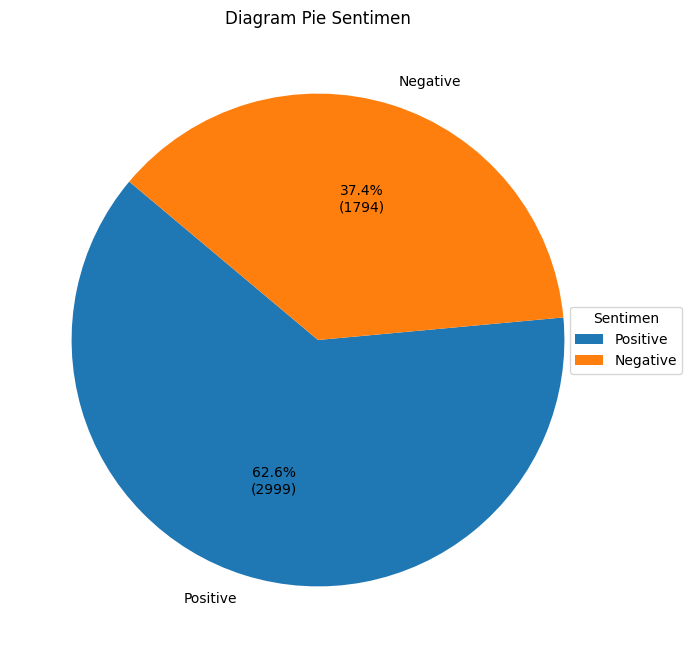

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.pie(sentimen_counts, labels=sentimen_counts.index, autopct=lambda p: '{:.1f}%\n({:.0f})'.format(p, p * sum(sentimen_counts) / 100),
        startangle=140)

plt.legend(sentimen_counts.index, title='Sentimen', loc='center', bbox_to_anchor=(1, 0.5))
plt.title('Diagram Pie Sentimen')

plt.savefig('diagram_sentimen.png')  # Gantilah 'diagram_sentimen.png' sesuai dengan nama file yang Anda inginkan
plt.show()
plt.close()

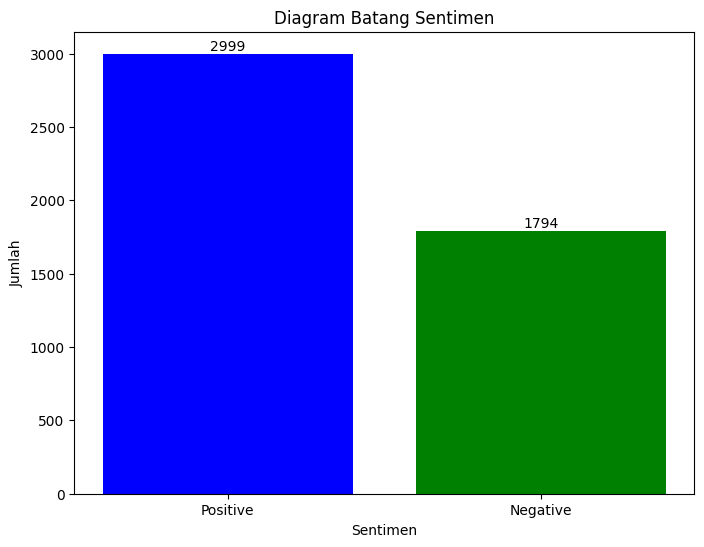

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#sentimen count
sentimen_counts = translate['sentiment'].value_counts()

#mengatur visualisasi diagram batang
plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'red']  #pemilihan warna (opsional)

#membuat plot diagram batang
bars = plt.bar(sentimen_counts.index, sentimen_counts.values, color=colors)

#menambahkan nilai di atas setiap batang
for bar, count in zip(bars, sentimen_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, count + 0.5, str(count), ha='center', va='bottom')

#pemberian label dan judul
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')
plt.title('Diagram Batang Sentimen')

plt.savefig('diagram_batang_sentimen.png')
plt.show()
plt.close()

menyimpan hasil labeling

In [ ]:
#simpan kedalam csv
translate.to_csv('hasil-labelin_DAY6.csv', sep=',', index=False)

## Eksplorasi Data Analys (EDA)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import string

import nltk
from nltk.corpus import stopwords
from nltk import word_tokenize
from nltk import pos_tag
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud,STOPWORDS

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

nltk.download('stopwords')
nltk.download('wordnet')

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC, NuSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


load dataset hasil labeling.


In [ ]:
#masukan data hasil labeling
df = pd.read_csv('/content/hasil-labelin_DAY6.csv')
df.head()

,full_text,id_str,created_at,username,user_id_str,lang,location,quote_count,reply_count,retweet_count,...,case_folding,tokenisasi,normalisasi,negation_converted_text,stopword_removal,stemming,to_sentence,english,polarity,sentiment
0,Fakta-fakta DAY6 yang Bakal Konser di Tiga Kota di Indonesia https://t.co/H8KAiLzktM #TempoSeleb,1.838509e+18,2024-09-24 09:23:08+00:00,tempodotco,1.812994e+07,in,Indonesia,0,0,0,...,fakta fakta day yang bakal konser di tiga kota di indonesia temposeleb,"['fakta', 'fakta', 'day', 'yang', 'bakal', 'konser', 'di', 'tiga', 'kota', 'di', 'indonesia', 'temposeleb']","['fakta', 'fakta', 'day', 'yang', 'bakal', 'konser', 'di', 'tiga', 'kota', 'di', 'indonesia', 'temposeleb']","['fakta', 'fakta', 'day', 'yang', 'bakal', 'konser', 'di', 'tiga', 'kota', 'di', 'indonesia', 'temposeleb']","['fakta', 'fakta', 'day', 'yang', 'konser', 'kota', 'indonesia', 'temposeleb']","['fakta', 'fakta', 'day', 'yang', 'konser', 'kota', 'indonesia', 'temposeleb']",fakta fakta day yang konser kota indonesia temposeleb,Facts of Day that will concert in three cities in Indonesia Temposeleb,0.000000,Negative
1,temen kantor w yang suka day6 dan jarang ngetweet mau ngasih freebies pas konser terus w bilang biasanya nanti yang terima freebies suka ngajak mutualan di twitter terus dia bilang kalo gw kasih LinkedIn gw aja boleh ga? nanti ngobrolnya di LinkedIn,1.838525e+18,2024-09-24 10:26:01+00:00,bandeusshi,8.452808e+17,in,Indonesia,762,94,1597,...,temen kantor w yang suka day dan jarang ngetweet mau ngasih freebies pas konser terus w bilang biasanya nanti yang terima freebies suka ngajak mutualan di twitter terus dia bilang kalo gw kasih linkedin gw aja boleh ga nanti ngobrolnya di linkedin,"['temen', 'kantor', 'w', 'yang', 'suka', 'day', 'dan', 'jarang', 'ngetweet', 'mau', 'ngasih', 'freebies', 'pas', 'konser', 'terus', 'w', 'bilang', 'biasanya', 'nanti', 'yang', 'terima', 'freebies', 'suka', 'ngajak', 'mutualan', 'di', 'twitter', 'terus', 'dia', 'bilang', 'kalo', 'gw', 'kasih', 'l...","['teman', 'kantor', 'gue', 'yang', 'suka', 'day', 'dan', 'jarang', 'ngetweet', 'mau', 'mengasih', 'freebies', 'pas', 'konser', 'terus', 'gue', 'bilang', 'biasanya', 'nanti', 'yang', 'terima', 'freebies', 'suka', 'mengajak', 'mutualan', 'di', 'twitter', 'terus', 'dia', 'bilang', 'kalo', 'gue', 'k...","['teman', 'kantor', 'gue', 'yang', 'suka', 'day', 'dan', 'jarang', 'ngetweet', 'mau', 'mengasih', 'freebies', 'pas', 'konser', 'terus', 'gue', 'bilang', 'biasanya', 'nanti', 'yang', 'terima', 'freebies', 'suka', 'mengajak', 'mutualan', 'di', 'twitter', 'terus', 'dia', 'bilang', 'kalo', 'gue', 'k...","['teman', 'kantor', 'gue', 'yang', 'suka', 'day', 'jarang', 'ngetweet', 'mau', 'mengasih', 'freebies', 'pas', 'konser', 'gue', 'bilang', 'yang', 'terima', 'freebies', 'suka', 'mengajak', 'mutualan', 'twitter', 'bilang', 'gue', 'kasih', 'linkedin', 'gue', 'saja', 'enggak_nanti', 'ngobrolnya', 'li...","['teman', 'kantor', 'gue', 'yang', 'suka', 'day', 'jarang', 'ngetweet', 'mau', 'mengasih', 'freebies', 'pas', 'konser', 'gue', 'bilang', 'yang', 'terima', 'freebies', 'suka', 'ajak', 'mutualan', 'twitter', 'bilang', 'gue', 'kasih', 'linkedin', 'gue', 'saja', 'enggak nanti', 'ngobrolnya', 'linked...",teman kantor gue yang suka day jarang ngetweet mau mengasih freebies pas konser gue bilang yang terima freebies suka ajak mutualan twitter bilang gue kasih linkedin gue saja enggak nanti ngobrolnya linkedin,"Friends of the office W who like to day and rarely tweet want to give freebies when the concert continues to say that usually later the one who receives freebies likes to invite quality on twitter and then he says if I give me LinkedIn, I may not later chat it on LinkedIn LinkedIn",0.100000,Positive
2,halooo temen-temen myday kalo masih bingung mau makan apa di konser surabaya nanti bisa cus pesen di aku yaah jangan sampai kelaparan #DAY6_FOREVER_YOUNG_Indonesia #DAY6_FOREVER_YOUNG_Surabaya,1.838579e+18,2024-09-24 14:00:41+00:00,cachoonne,8.777371e+17,in,24,0,0,

In [ ]:
print("Beberapa Baris Pertama Dataset:")
print(df.head())

Beberapa Baris Pertama Dataset:
                                                                                                                                                                                                                                                                       full_text  \
0                                                                                                                                                                               Fakta-fakta DAY6 yang Bakal Konser di Tiga Kota di Indonesia https://t.co/H8KAiLzktM #TempoSeleb   
1                     temen kantor w yang suka day6 dan jarang ngetweet mau ngasih freebies pas konser terus w bilang biasanya nanti yang terima freebies suka ngajak mutualan di twitter terus dia bilang kalo gw kasih LinkedIn gw aja boleh ga? nanti ngobrolnya di LinkedIn    
2                                                                               halooo temen-temen myday kalo masih bingung mau makan apa di

In [ ]:
print("\nInformasi Dataset:")
print(df.info())


Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4793 entries, 0 to 4792
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   full_text                4793 non-null   object 
 1   id_str                   4793 non-null   float64
 2   created_at               4793 non-null   object 
 3   username                 4793 non-null   object 
 4   user_id_str              4793 non-null   float64
 5   lang                     4793 non-null   object 
 6   location                 4793 non-null   object 
 7   quote_count              4793 non-null   int64  
 8   reply_count              4793 non-null   int64  
 9   retweet_count            4793 non-null   int64  
 10  favorite_count           4793 non-null   int64  
 11  tweet_url                4793 non-null   object 
 12  mentions                 4793 non-null   object 
 13  mention_count            4793 non-null   int64  
 14  sour

statistik deskriptif jumalah teks

In [ ]:
df['text_length'] = df['full_text'].apply(lambda x: len(x.split()))

In [ ]:
print("\nStatistik Deskriptif Teks (Panjang Teks):")
print(f"Rata-rata panjang teks: {df['text_length'].mean()} kata")
print(f"Panjang teks terpendek: {df['text_length'].min()} kata")
print(f"Panjang teks terpanjang: {df['text_length'].max()} kata")


Statistik Deskriptif Teks (Panjang Teks):
Rata-rata panjang teks: 23.688295430836636 kata
Panjang teks terpendek: 2 kata
Panjang teks terpanjang: 58 kata


In [ ]:
df['panjang_teks'] = df['sentiment'].apply(len)
df.groupby('sentiment')['panjang_teks'].describe()

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
Negative,1794.0,8.0,0.0,8.0,8.0,8.0,8.0,8.0
Positive,2999.0,8.0,0.0,8.0,8.0,8.0,8.0,8.0


frekuensi kata (Word Clouds)

In [ ]:
all_text = ' '.join(df['full_text'])
wordcloud = WordCloud(stopwords=stopwords.words('english'), background_color='white').generate(all_text)

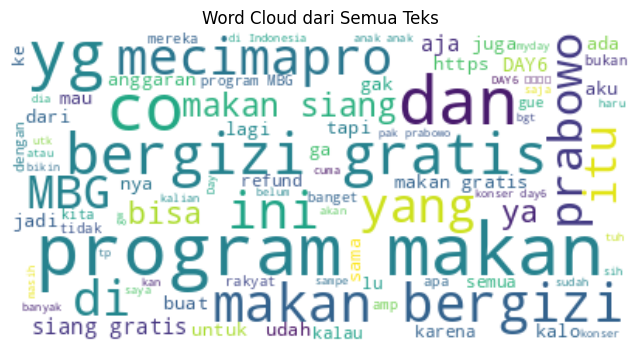

In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud dari Semua Teks')
plt.show()

Frekuensi Data

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer
# Using max_features to limit the number of features and avoid a very large matrix
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit and transform the 'to_sentence' column
# We need to handle potential NaN values in 'to_sentence'
df['to_sentence'] = df['to_sentence'].fillna('') # Replace NaN with empty string
X = tfidf_vectorizer.fit_transform(df['to_sentence'])

print("Shape of the TF-IDF matrix:", X.shape)

Shape of the TF-IDF matrix: (4793, 5000)


In [ ]:
from collections import Counter
word_freq = Counter(' '.join(df['full_text']).split())
top_words = word_freq.most_common(10)

In [ ]:
print("\n10 Kata Teratas yang Paling Sering Muncul:")
for word, freq in top_words:
    print(f"{word}: {freq}")


10 Kata Teratas yang Paling Sering Muncul:
program: 1753
makan: 1516
di: 1254
gratis: 1239
yg: 1195
dan: 1072
@mecimapro: 1067
MBG: 1001
yang: 957
ini: 905


In [ ]:
positive_words = ' '.join(df[df['sentiment'] == 'Positive']['to_sentence'])
negative_words = ' '.join(df[df['sentiment'] == 'Negative']['to_sentence'])

In [ ]:
def plot_wordcloud(text, title):
    wordcloud = WordCloud(stopwords=stopwords.words('english'), background_color='white').generate(text)
    plt.figure(figsize=(8, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

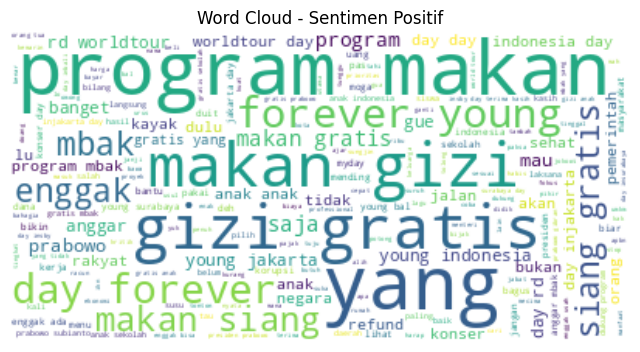

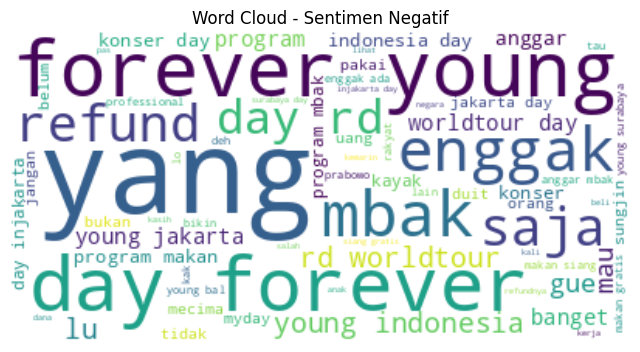

In [ ]:
plot_wordcloud(positive_words, 'Word Cloud - Sentimen Positif')
plot_wordcloud(negative_words, 'Word Cloud - Sentimen Negatif')

Distribusi Teks dengan Diagram Boxplot

In [ ]:
print(df.columns)

Index(['full_text', 'id_str', 'created_at', 'username', 'user_id_str', 'lang',
       'location', 'quote_count', 'reply_count', 'retweet_count',
       'favorite_count', 'tweet_url', 'mentions', 'mention_count', 'source',
       'target', 'remove_user', 'cleaning', 'case_folding', 'tokenisasi',
       'normalisasi', 'negation_converted_text', 'stopword_removal',
       'stemming', 'to_sentence', 'english', 'polarity', 'sentiment',
       'text_length', 'panjang_teks'],
      dtype='object')


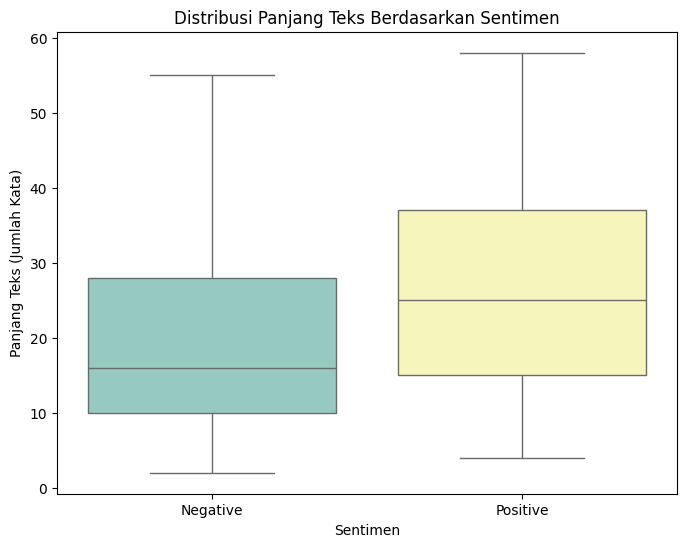

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='sentiment', y='text_length', palette='Set3')
plt.title('Distribusi Panjang Teks Berdasarkan Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Panjang Teks (Jumlah Kata)')
plt.show()

## Visualisasi Distribusi Data dan Fitur

memeriksa distribusi jumlah data di setiap kelas dari kolom target (sentiment).

In [ ]:
import pandas as pd

data = pd.read_csv("/content/hasil-labelin_DAY6.csv")
print(data["sentiment"].value_counts())

sentiment
Positive    2999
Negative    1794
Name: count, dtype: int64


In [ ]:
print(df['sentiment'].value_counts(normalize=True))

sentiment
Positive    0.625704
Negative    0.374296
Name: proportion, dtype: float64


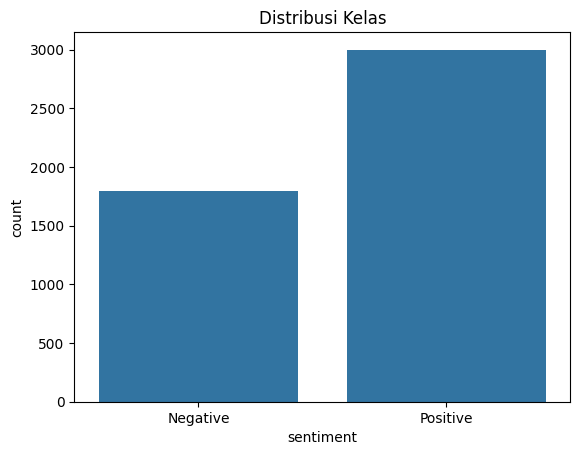

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="sentiment", data=data)
plt.title("Distribusi Kelas")
plt.show()


## Model Traning